In [59]:
import pandas as pd
import numpy as np
import matplotlib as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix

In [32]:
df=pd.read_csv('credit_card_fraud_2026.csv')

In [33]:
df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [34]:
df.columns

Index(['transaction_id', 'amount_usd', 'merchant_category', 'card_type',
       'auth_method', 'channel', 'device_type', 'is_foreign_transaction',
       'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km',
       'card_age_months', 'customer_age', 'account_balance_usd',
       'is_new_merchant', 'used_vpn', 'ip_country_mismatch',
       'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score',
       'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt',
       'merchant_risk_score', 'prior_disputes', 'is_fraud'],
      dtype='str')

In [35]:
df.isnull().sum()

transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  str    
 3   card_type                     20000 non-null  str    
 4   auth_method                   20000 non-null  str    
 5   channel                       20000 non-null  str    
 6   device_type                   20000 non-null  str    
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  account_bala

In [37]:
print(df["is_fraud"].value_counts())


is_fraud
0    19661
1      339
Name: count, dtype: int64


In [38]:
print(df.shape)

(20000, 26)


In [39]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


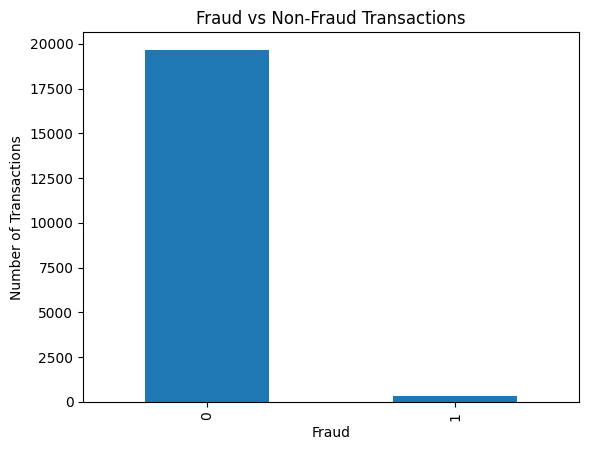

In [40]:
import matplotlib.pyplot as plt

df["is_fraud"].value_counts().plot(kind="bar")

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Number of Transactions")
plt.show()

In [41]:
num_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

print(num_cols)

Index(['transaction_id', 'amount_usd', 'hours_since_last_txn',
       'txn_count_last_24h', 'distance_from_home_km', 'card_age_months',
       'customer_age', 'account_balance_usd', 'cvv_retry_count',
       'velocity_score', 'time_of_day_hour', 'day_of_week',
       'merchant_risk_score', 'prior_disputes', 'is_fraud'],
      dtype='str')


In [42]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,20000.0,10000.500000,5773.647028,1.00,5000.7500,10000.500,15000.2500,20000.00
amount_usd,20000.0,132.424597,256.963666,1.00,26.2350,57.510,131.7525,6872.69
hours_since_last_txn,20000.0,8.950827,8.838745,0.01,2.5900,6.210,12.4325,87.05
txn_count_last_24h,20000.0,3.191650,1.779544,0.00,2.0000,3.000,4.0000,12.00
distance_from_home_km,20000.0,22.139525,22.120960,0.00,6.3375,15.505,30.8200,216.19
card_age_months,20000.0,46.937550,6.768577,22.00,42.0000,47.000,51.0000,74.00
customer_age,20000.0,49.669400,18.494032,18.00,34.0000,50.000,66.0000,81.00
account_balance_usd,20000.0,3316.662598,4350.720948,52.05,1019.1400,2007.685,3944.1200,127125.86
cvv_retry_count,20000.0,0.181300,0.422302,0.00,0.0000,0.000,0.0000,3.00
velocity_score,20000.0,19.807735,12.366301,0.00,10.7000,18.800,27.6000,74.40


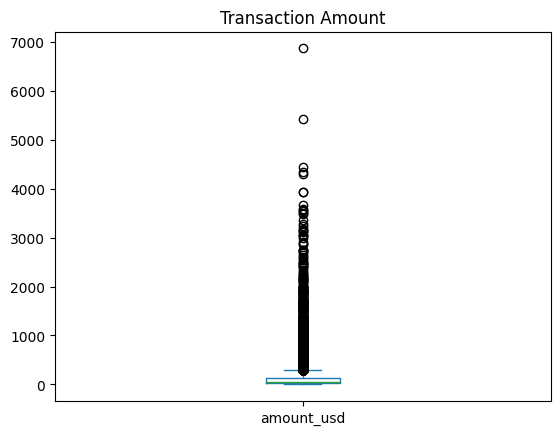

In [43]:
import matplotlib.pyplot as plt

df["amount_usd"].plot(kind="box")

plt.title("Transaction Amount")
plt.show()

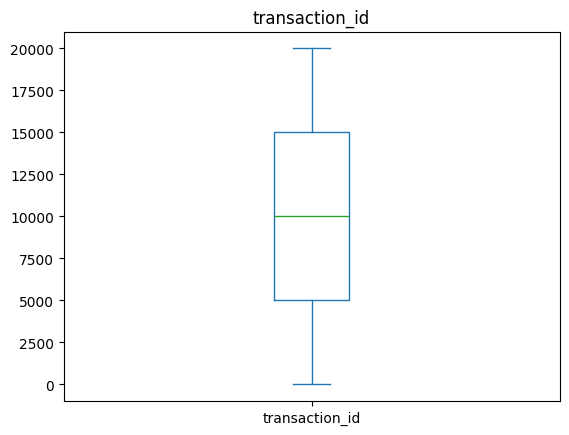

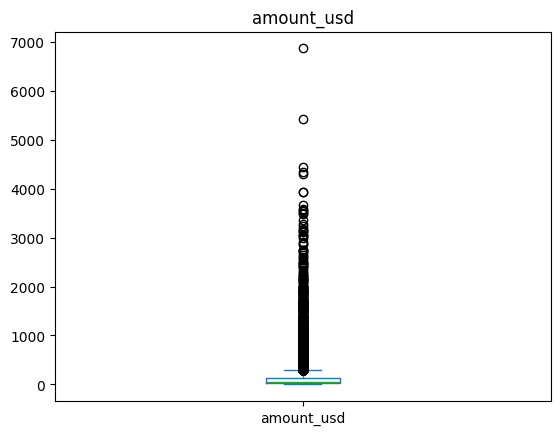

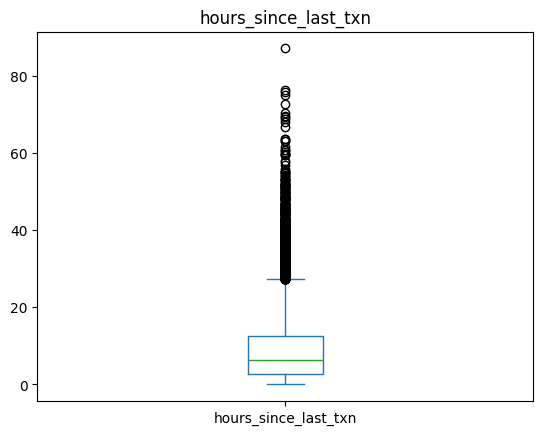

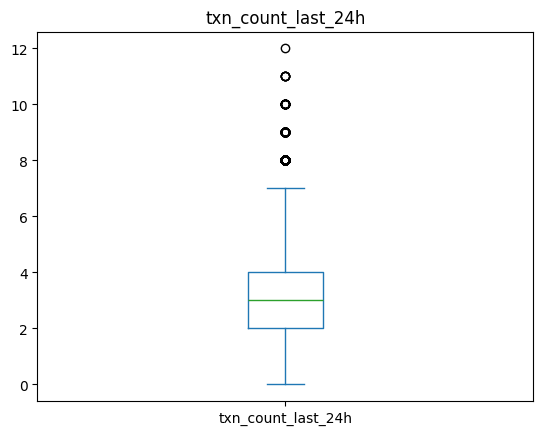

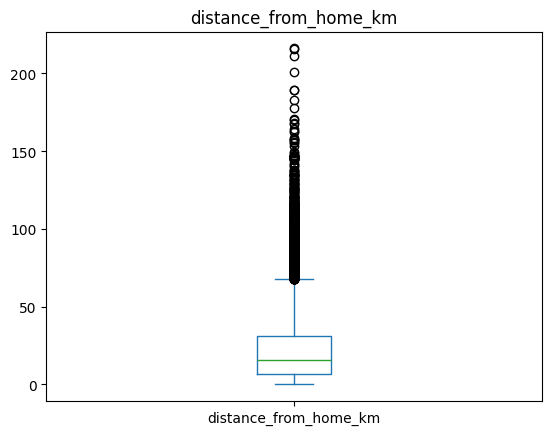

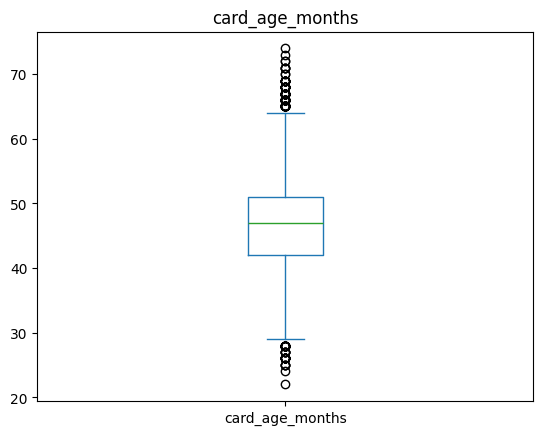

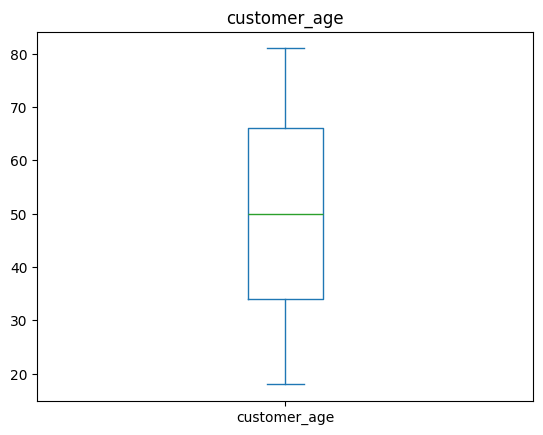

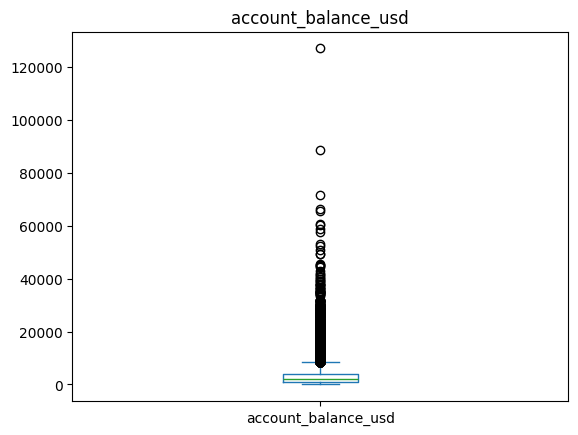

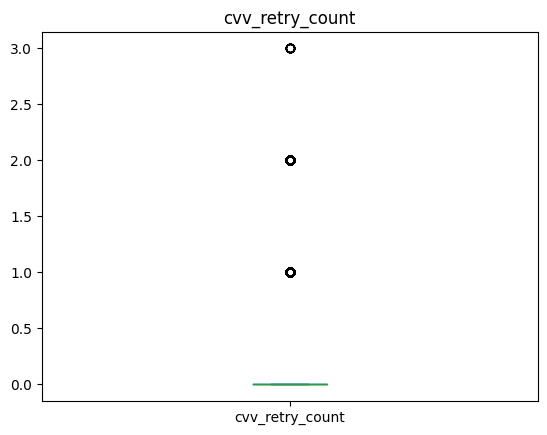

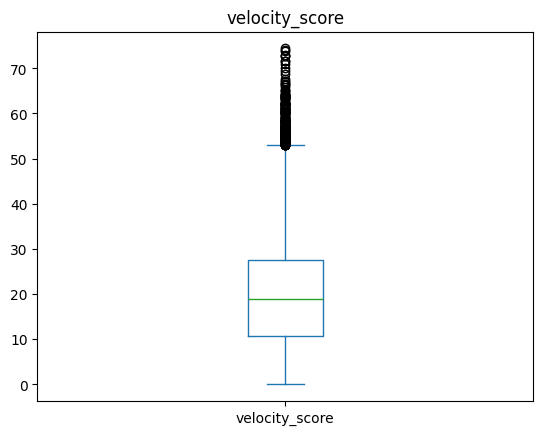

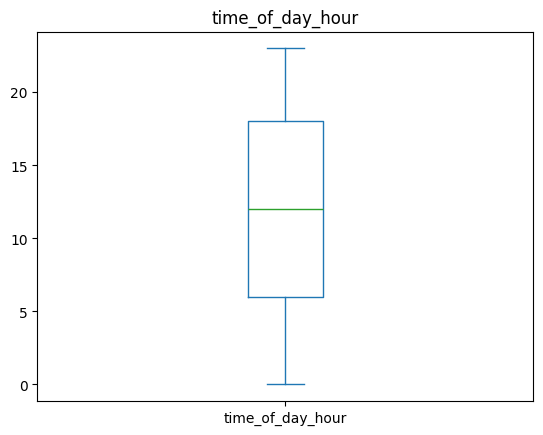

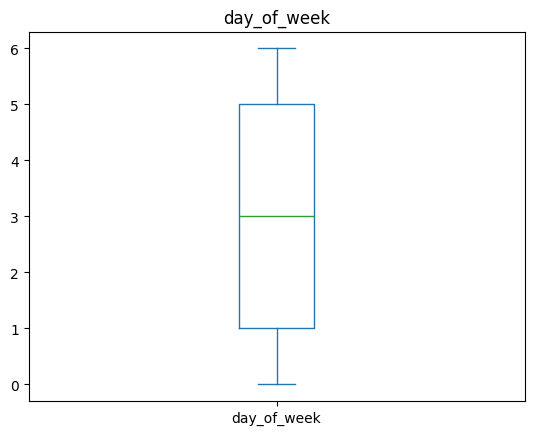

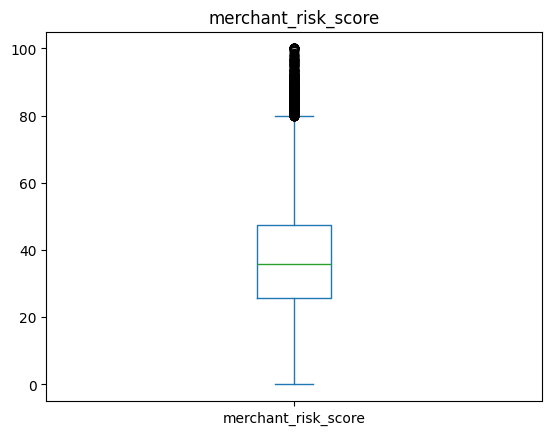

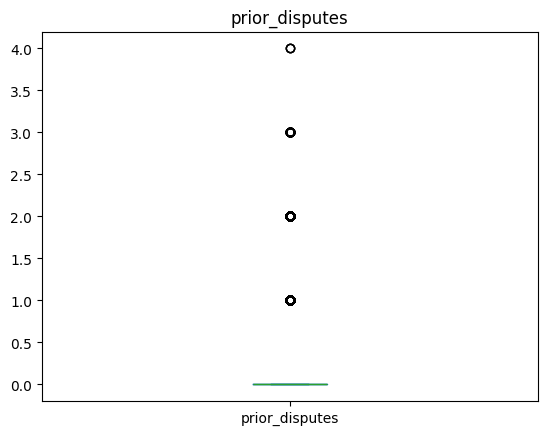

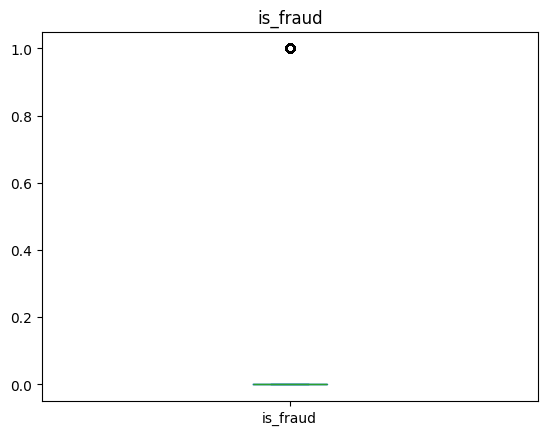

In [44]:
for col in num_cols:
    df[col].plot(kind="box")
    plt.title(col)
    plt.show()

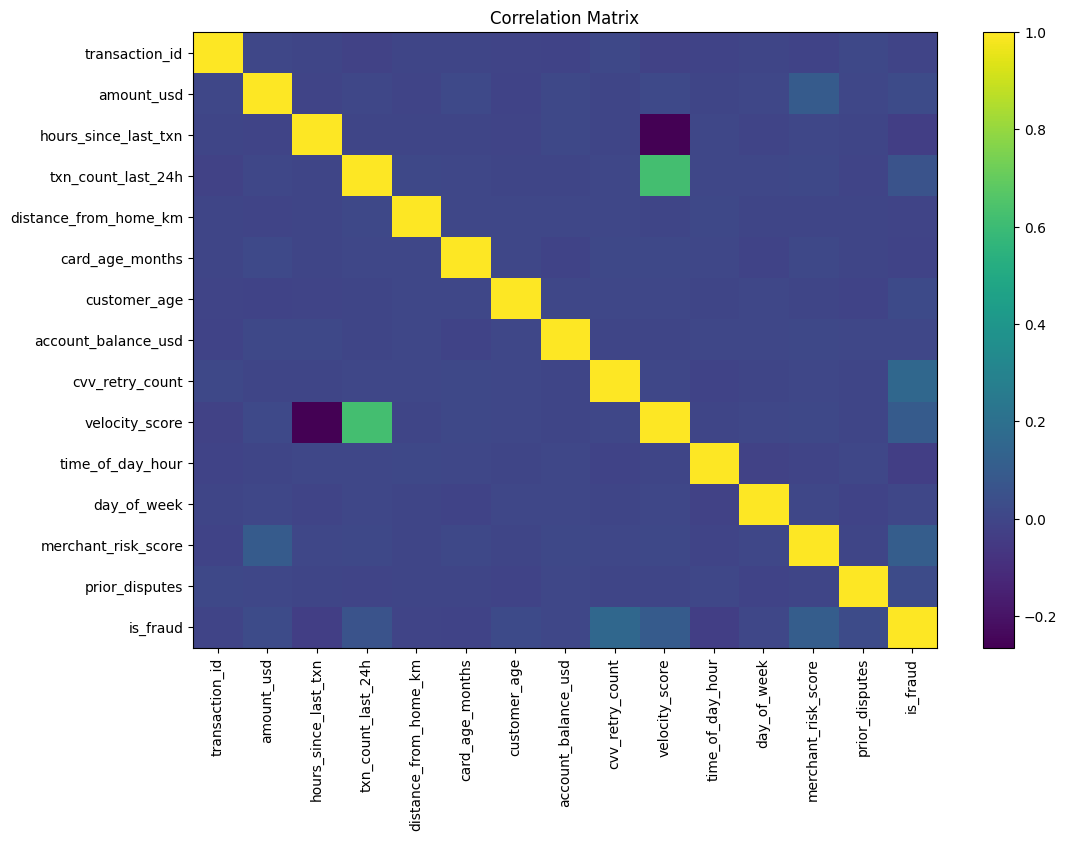

In [45]:
corr = df[num_cols].corr()

plt.figure(figsize=(12, 8))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(num_cols)),
    num_cols,
    rotation=90
)

plt.yticks(
    range(len(num_cols)),
    num_cols
)

plt.title("Correlation Matrix")

plt.show()

In [46]:
corr

,transaction_id,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
transaction_id,1.000000,0.002441,-0.000601,-0.014184,0.001049,-0.003042,-0.005116,-0.011393,0.009363,-0.014253,-0.009452,-0.002361,-0.011370,0.009324,-0.005357
amount_usd,0.002441,1.000000,-0.004697,0.006365,-0.005460,0.012348,-0.010271,0.009512,-0.001462,0.014076,0.001197,0.005786,0.097103,0.003770,0.024951
hours_since_last_txn,-0.000601,-0.004697,1.000000,0.000508,-0.002970,-0.001885,-0.006366,0.007882,0.000617,-0.265509,0.002550,-0.006053,0.002697,0.000656,-0.028798
txn_count_last_24h,-0.014184,0.006365,0.000508,1.000000,0.006385,0.002571,0.001216,0.000606,0.005594,0.622395,0.005086,0.005323,0.006560,-0.004462,0.059866
distance_from_home_km,0.001049,-0.005460,-0.002970,0.006385,1.000000,0.004566,0.005347,0.002393,0.002889,-0.003026,0.011272,-0.002326,0.000702,-0.000854,-0.004292
card_age_months,-0.003042,0.012348,-0.001885,0.002571,0.004566,1.000000,0.005039,-0.008965,0.010276,0.009421,0.003870,-0.010024,0.006808,-0.000289,-0.012065
customer_age,-0.005116,-0.010271,-0.006366,0.001216,0.005347,0.005039,1.000000,0.004879,0.003449,0.002320,0.000728,0.001936,-0.000441,-0.010562,0.019543
account_balance_usd,-0.011393,0.009512,0.007882,0.000606,0.002393,-0.008965,0.004879,1.000000,0.000855,-0.002497,0.004680,0.004286,0.007838,0.003973,0.004371
cvv_retry_count,0.009363,-0.001462,0.000617,0.005594,0.002889,0.010276,0.003449,0.000855,1.000000,0.006100,-0.012054,0.000681,0.001961,0.000266,0.155509
velocity_score,-0.014253,0.014076,-0.265509,0.622395,-0.003026,0.009421,0.002320,-0.002497,0.006100,1.000000,0.000661,0.004900,0.006441,-0.002784,0.097255


In [47]:
X = df.drop(columns=["transaction_id", "is_fraud"]).copy()

bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

In [52]:
categorical_cols = X.select_dtypes(include=["str"]).columns

boolean_cols = X.select_dtypes(include=["bool"]).columns

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns

print("Categorical:", list(categorical_cols))
print("Boolean:", list(boolean_cols))
print("Numerical:", list(numerical_cols))

Categorical: ['merchant_category', 'card_type', 'auth_method', 'channel', 'device_type']
Boolean: []
Numerical: ['amount_usd', 'is_foreign_transaction', 'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km', 'card_age_months', 'customer_age', 'account_balance_usd', 'is_new_merchant', 'used_vpn', 'ip_country_mismatch', 'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score', 'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt', 'merchant_risk_score', 'prior_disputes']


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import IsolationForest

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

print("Original shape:", X.shape)
print("Processed shape:", X_processed.shape)

Original shape: (20000, 24)
Processed shape: (20000, 54)


In [54]:
 X_processed

array([[-0.34855837, -0.25709547,  0.51922386, ...,  0.        ,
         0.        ,  0.        ],
       [-0.49687098, -0.25709547, -0.93237599, ...,  0.        ,
         0.        ,  0.        ],
       [-0.21499529, -0.25709547, -0.97310678, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.47546664, -0.25709547,  1.32591965, ...,  1.        ,
         0.        ,  0.        ],
       [-0.39339073, -0.25709547,  1.58274986, ...,  0.        ,
         0.        ,  0.        ],
       [-0.32972255, -0.25709547, -0.87693687, ...,  0.        ,
         0.        ,  1.        ]], shape=(20000, 54))

In [55]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.017,
    random_state=42
)

model.fit(X_processed)


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.017
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [56]:
predictions = model.predict(X_processed)

df["anomaly"] = predictions

df["anomaly"] = df["anomaly"].map({
    1: 0,
    -1: 1
})


In [57]:

print("\nAnomaly counts:")
print(df["anomaly"].value_counts())


Anomaly counts:
anomaly
0    19660
1      340
Name: count, dtype: int64


In [60]:

print("\nConfusion Matrix:")
print(confusion_matrix(
    df["is_fraud"],
    df["anomaly"]
))

print("\nClassification Report:")
print(classification_report(
    df["is_fraud"],
    df["anomaly"]
))


Confusion Matrix:
[[19393   268]
 [  267    72]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19661
           1       0.21      0.21      0.21       339

    accuracy                           0.97     20000
   macro avg       0.60      0.60      0.60     20000
weighted avg       0.97      0.97      0.97     20000



In [61]:
df["anomaly_score"] = model.decision_function(X_processed)

print(
    df.groupby("is_fraud")["anomaly_score"].describe()
)

            count      mean       std       min       25%       50%       75%  \
is_fraud                                                                        
0         19661.0  0.050047  0.021006 -0.040229  0.036163  0.051345  0.065373   
1           339.0  0.018288  0.022016 -0.041032  0.002607  0.019567  0.032192   

               max  
is_fraud            
0         0.105249  
1         0.083683  
